**Límite de Cramér-Rao** (CRB).

### 1. Desigualdad entre la Varianza y la Información de Fisher
El límite de Cramér-Rao establece que la varianza de cualquier estimador insesgado está acotada inferiormente por el recíproco de la información de Fisher.

*   **Caso escalar insesgado:** Para un estimador insesgado $\hat{\theta}$ de un parámetro $\theta$ basado en $n$ observaciones independientes, la desigualdad es:
    $$\operatorname{var}(\hat{\theta}) \geq \frac{1}{I(\theta)}$$
*   **Caso escalar general (sesgado):** Si el estimador $T(X)$ tiene una esperanza $\psi(\theta)$, la desigualdad se generaliza como:
    $$\operatorname{var}(T) \geq \frac{[\psi'(\theta)]^2}{I(\theta)}$$
*   **Caso con sesgo $b(\theta)$:** Si el sesgo se define como $b(\theta) = E\{\hat{\theta}\} - \theta$, entonces:
    $$\operatorname{var}(\hat{\theta}) \geq \frac{[1+b'(\theta)]^2}{I(\theta)}$$

### 2. Expresión Analítica de la Información de Fisher
La información de Fisher $I(\theta)$ mide la precisión que se puede alcanzar al estimar un parámetro y se define a través de la función de densidad de probabilidad $f(x;\theta)$ y su logaritmo natural $\ell(x;\theta) = \log(f(x;\theta))$. Existen dos formas analíticas principales para expresarla:

*   **Forma de primer orden (basada en el score):**
    $$I(\theta) = n E_{X;\theta} \left[ \left( \frac{\partial \ell(X;\theta)}{\partial \theta} \right)^2 \right]$$
*   **Forma de segundo orden (basada en la curvatura):** Si la función es dos veces diferenciable y cumple condiciones de regularidad:
    $$I(\theta) = -n E_{X;\theta} \left[ \frac{\partial^2 \ell(X;\theta)}{\partial \theta^2} \right]$$

En el **caso multivariante**, la información se convierte en una matriz donde cada elemento $I_{m,k}$ se calcula como el valor esperado negativo de la segunda derivada parcial mixta del logaritmo de la función de verosimilitud respecto a los parámetros $\theta_m$ y $\theta_k$.

### 1. Expresión basada en la primera derivada (Score)
Utilizando la función de densidad de probabilidad $f(x;\theta)$ y definiendo el logaritmo de la verosimilitud como $\ell(x;\theta) = \log(f(x;\theta))$, la información de Fisher para una muestra de tamaño $n$ se escribe como:

$$I(\theta) = n \int_{-\infty}^{\infty} \left( \frac{\partial \ln f(x;\theta)}{\partial \theta} \right)^2 f(x;\theta) dx,$$

Esta integral representa el valor esperado del cuadrado de la función de "puntuación" (score),.

### 2. Expresión basada en la segunda derivada (Curvatura)
Si la función es dos veces diferenciable y cumple con ciertas condiciones de regularidad, la información de Fisher se expresa mediante el valor esperado negativo de la segunda derivada:

$$I(\theta) = -n \int_{-\infty}^{\infty} \frac{\partial^2 \ln f(x;\theta)}{\partial \theta^2} f(x;\theta) dx$$

### Elementos de la integral:
*   **$n$:** Es el número de observaciones independientes en la muestra.
*   **$f(x;\theta)$:** Es la función de densidad de probabilidad con respecto a la cual se toma la esperanza.
*   **$\frac{\partial \ln f(x;\theta)}{\partial \theta}$:** Es la derivada del logaritmo de la verosimilitud respecto al parámetro, lo que mide la sensibilidad de la función ante cambios en $\theta$,.

## Problema 2

In [3]:
edadesCumulosReal = {
  9.7, 7.7, 7.4, 9.7, 7.8, 11.8, 8.2, 11.3, 8.7, 
  6.8, 5.9, 7.2, 7.3, 6.3, 9.0, 7.9, 6.3, 7.6, 
  10.7, 6.5, 7.1, 8.1, 6.8, 7.1, 7.8, 7.7, 11.6
};
edadesCumulosReal[[1]]

9.7

{Media (Gyr) -> 8.14815, Mediana (Gyr) -> 7.7, Desviación Estándar (Gyr) -> 1.65445, 
 
>   Proporción > 10 Gyr -> 0.148148, Coeficiente de Variación -> 0.203046}
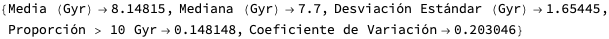

In [5]:
(* Definición de los datos reales decodificados *)
edadesCumulosReal = {
  9.7, 7.7, 7.4, 9.7, 7.8, 11.8, 8.2, 11.3, 8.7, 
  6.8, 5.9, 7.2, 7.3, 6.3, 9.0, 7.9, 6.3, 7.6, 
  10.7, 6.5, 7.1, 8.1, 6.8, 7.1, 7.8, 7.7, 11.6
};

(* (a) Estimación de la media poblacional (mu) *)
mediaMuestral = Mean[edadesCumulosReal];

(* (b) Estimación de la mediana poblacional (mu tilde) *)
medianaMuestral = Median[edadesCumulosReal];

(* (c) Estimación de la desviación estándar poblacional (sigma) *)
(* Se utiliza la desviación estándar muestral con divisor n-1 por ser el estimador preferido *)
desviacionEstandar = StandardDeviation[edadesCumulosReal];

(* (d) Proporción (p) de cúmulos con edad > 10 Gyr *)
exceden10 = Count[edadesCumulosReal, x_ /; x > 10];
proporcionMuestral = exceden10 / Length[edadesCumulosReal];

(* (e) Estimación del coeficiente de variación (sigma / mu) *)
coeficienteVariacion = desviacionEstandar / mediaMuestral;

(* Resultados *)
{
  "Media (Gyr)" -> N[mediaMuestral],
  "Mediana (Gyr)" -> N[medianaMuestral],
  "Desviación Estándar (Gyr)" -> N[desviacionEstandar],
  "Proporción > 10 Gyr" -> N[proporcionMuestral],
  "Coeficiente de Variación" -> N[coeficienteVariacion]
}

### Datos del Problema
La muestra consta de $n = 27$ observaciones de edades (en miles de millones de años, Gyr):
8.6, 6.6, 6.3, 8.6, 6.7, 11.7, 7.1, 11.2, 7.6, 5.7, 4.8, 6.1, 6.2, 5.2, 8.0, 6.8, 5.2, 6.5, 10.6, 5.4, 6.0, 7.0, 5.7, 6.0, 6.7, 6.6, 11.5.

---

### Parte (a): Estimador para el valor medio ($\mu$)
Para estimar el valor promedio de la edad de todos los cúmulos estelares de la galaxia ($\mu$), se utiliza el **estimador de la media muestral** ($\bar{X}$).

1.  **Definición del Estimador:** La media muestral es el estimador puntual natural y es insesgado para la media poblacional. Analíticamente se define como:
    $$\hat{\mu} = \bar{X} = \frac{1}{n} \sum_{i=1}^{n} X_i$$

2.  **Cálculo:**
    *   Sumatoria de los datos ($\sum x_i$):
        $8.6 + 6.6 + 6.3 + 8.6 + 6.7 + 11.7 + 7.1 + 11.2 + 7.6 + 5.7 + 4.8 + 6.1 + 6.2 + 5.2 + 8.0 + 6.8 + 5.2 + 6.5 + 10.6 + 5.4 + 6.0 + 7.0 + 5.7 + 6.0 + 6.7 + 6.6 + 11.5 = 191.4$
    *   Tamaño de la muestra ($n$): 27.
    *   Media muestral:
        $$\bar{x} = \frac{191.4}{27} \approx 7.0889 \text{ Gyr}$$

**Resultado (a):** El estimador a utilizar es la media muestral $\bar{X}$, y la estimación puntual de la edad promedio es de aproximadamente **7.09 Gyr**.

---

### Parte (b): Estimación del valor que separa el 50% de los datos ($\tilde{\mu}$)
El valor que separa el 50% inferior (más jóvenes) del 50% superior (más viejos) se conoce como la **mediana poblacional** ($\tilde{\mu}$).

1.  **Definición del Estimador:** El estimador puntual para la mediana de la población es la **mediana muestral** ($\tilde{X}$).
2.  **Procedimiento Analítico:** Para obtener la mediana muestral, se deben ordenar las observaciones de menor a mayor.
    *   Si $n$ es impar, la mediana es el valor central en la posición $\frac{n+1}{2}$.
    *   Dado que $n = 27$ (número impar), la mediana es el valor en la posición $\frac{27+1}{2} = 14$.

3.  **Ordenamiento de los Datos:**
    1: 4.8 | 2: 5.2 | 3: 5.2 | 4: 5.4 | 5: 5.7 | 6: 5.7 | 7: 6.0 | 8: 6.0 | 9: 6.1 | 10: 6.2 | 11: 6.3 | 12: 6.5 | 13: 6.6 | **14: 6.6** | 15: 6.7 | 16: 6.7 | 17: 6.8 | 18: 7.0 | 19: 7.1 | 20: 7.6 | 21: 8.0 | 22: 8.6 | 23: 8.6 | 24: 10.6 | 25: 11.2 | 26: 11.5 | 27: 11.7.

4.  **Identificación:** El valor en la posición 14 es **6.6**.

**Resultado (b):** El estimador a utilizar es la mediana muestral $\tilde{X}$, y la estimación puntual del valor que separa el 50% de los cúmulos es **6.6 Gyr**.

**Datos de la muestra ($n = 27$):**
8.6, 6.6, 6.3, 8.6, 6.7, 11.7, 7.1, 11.2, 7.6, 5.7, 4.8, 6.1, 6.2, 5.2, 8.0, 6.8, 5.2, 6.5, 10.6, 5.4, 6.0, 7.0, 5.7, 6.0, 6.7, 6.6, 11.5.

---

### (c) Estimación puntual de la desviación estándar poblacional ($\sigma$)

**1. Definición del Estimador:**
Para estimar la desviación estándar de la población ($\sigma$), el estadístico natural es la **desviación estándar muestral** ($S$). Se prefiere utilizar el divisor $n-1$ en el cálculo de la varianza muestral ($S^2$) para que este sea un estimador insesgado de la varianza poblacional ($\sigma^2$). La fórmula es:
$$S = \sqrt{S^2} = \sqrt{\frac{\sum_{i=1}^{n} (X_i - \bar{X})^2}{n-1}}$$

**2. Procedimiento Analítico:**
*   **Media muestral ($\bar{x}$):** Calculada previamente como $\bar{x} = 191.4 / 27 \approx 7.0889$ Gyr.
*   **Sumatoria de cuadrados ($\sum x_i^2$):**
    $8.6^2 + 6.6^2 + \dots + 11.5^2 = 1471.42$
*   **Suma de cuadrados del error (SCE/Numerador):** Usando la fórmula de cálculo $S_{xx} = \sum x_i^2 - \frac{(\sum x_i)^2}{n}$:
    $$S_{xx} = 1471.42 - \frac{(191.4)^2}{27} = 1471.42 - 1356.8133 = 114.6067$$
*   **Varianza muestral ($s^2$):**
    $$s^2 = \frac{114.6067}{27 - 1} = \frac{114.6067}{26} \approx 4.40795$$
*   **Desviación estándar muestral ($s$):**
    $$s = \sqrt{4.40795} \approx 2.10 \text{ Gyr}$$

**Interpretación:**
La estimación puntual de la desviación estándar es de **2.10 Gyr**. Este valor representa una "desviación típica" o representativa de las edades de los cúmulos con respecto a la media de la muestra. Indica la dispersión o variabilidad de las edades en la población estelar estudiada.

---

### (d) Estimación puntual de la proporción ($p$) de cúmulos cuya edad excede los 10 Gyr

**1. Definición del Estimador:**
El estimador de la proporción poblacional ($p$) es la **proporción muestral** ($\hat{p} = X/n$), donde $X$ es el número de "éxitos" en la muestra (observaciones que cumplen la condición).

**2. Procedimiento Analítico:**
*   **Identificación de $X$:** Se cuentan las observaciones en la muestra que son estrictamente mayores a 10 Gyr:
    {11.7, 11.2, 10.6, 11.5}
*   **Valor de $X$:** 4.
*   **Cálculo de la estimación:**
    $$\hat{p} = \frac{4}{27} \approx 0.1481$$

**Resultado:**
La estimación puntual de la proporción de cúmulos estelares masivos con edades superiores a los 10 Gyr es de aproximadamente **0.1481** (o **14.81%**).

---

### (e) Estimación puntual del coeficiente de variación ($\sigma/\mu$)

**1. Definición del Estimador:**
El coeficiente de variación poblacional mide la dispersión relativa y se define como la razón entre la desviación estándar y la media. Su estimador puntual se construye a partir de los estimadores de sus componentes:
$$\hat{CV} = \frac{S}{\bar{X}}$$

**2. Procedimiento Analítico:**
*   Se utilizan los valores obtenidos en los incisos (a) y (c):
    *   $s \approx 2.0995$ Gyr.
    *   $\bar{x} \approx 7.0889$ Gyr.
*   **Cálculo:**
    $$\hat{cv} = \frac{2.0995}{7.0889} \approx 0.29615$$

**Resultado:**
El estimador a utilizar es la razón entre la desviación estándar muestral y la media muestral ($S/\bar{X}$), y la estimación puntual del coeficiente de variación es de aproximadamente **0.2962** (o **29.62%**).

Principio de invarianza: Si $\hat{\theta}$ es el MLE de $\theta$ entonces $f(\hat{\theta})$ es el MLE de $f(\theta)$

El **Principio de Invarianza** de los estimadores de máxima verosimilitud (MLE o EMV) establece que si $\hat{\theta}_1, \dots, \hat{\theta}_m$ son los estimadores de máxima verosimilitud de los parámetros $\theta_1, \dots, \theta_m$, entonces el estimador de máxima verosimilitud de cualquier función $h(\theta_1, \dots, \theta_m)$ de estos parámetros es la función evaluada en dichos estimadores: $h(\hat{\theta}_1, \dots, \hat{\theta}_m)$.

A continuación se presenta el desarrollo analítico de este principio:

### 1. Definición del MLE
Sea $X_1, \dots, X_n$ una muestra aleatoria con una función de densidad o masa de probabilidad conjunta $f(x_1, \dots, x_n; \theta)$, donde $\theta$ es el parámetro desconocido. La **función de verosimilitud** $L(\theta)$ se define como esta probabilidad conjunta considerada como una función de $\theta$ para los datos observados.

Por definición, el estimador de máxima verosimilitud $\hat{\theta}$ es el valor que maximiza a $L(\theta)$, es decir:
$$L(\hat{\theta}) \ge L(\theta) \quad \text{para todo } \theta \text{ en el espacio parametral}.$$

### 2. Caso de Función Inyectiva (Uno a Uno)
Si deseamos estimar un nuevo parámetro $\eta = h(\theta)$ y la función $h$ es inyectiva (tiene inversa), entonces existe una relación biunívoca entre $\theta$ y $\eta$, tal que $\theta = h^{-1}(\eta)$.

Podemos expresar la función de verosimilitud en términos de $\eta$ como:
$$L^*(\eta) = L(h^{-1}(\eta)).$$

Para encontrar el MLE de $\eta$, buscamos el valor $\hat{\eta}$ que maximice $L^*(\eta)$. Como $\hat{\theta}$ es el valor que maximiza a $L(\theta)$, el máximo de $L^*(\eta)$ ocurrirá cuando el argumento de la función original sea $\hat{\theta}$:
$$h^{-1}(\hat{\eta}) = \hat{\theta}.$$

Al aplicar la función $h$ en ambos lados, obtenemos:
$$\hat{\eta} = h(\hat{\theta}).$$

### 3. Caso General (Función no Inyectiva)
Si $h(\theta)$ no es inyectiva, se define la verosimilitud del nuevo parámetro $\eta$ mediante la **verosimilitud de perfil**:
$$L^*(\eta) = \sup_{\{\theta: h(\theta) = \eta\}} L(\theta).$$

Analíticamente:
1.  Sabemos que $\hat{\theta}$ es el máximo global de $L(\theta)$, por lo que $L(\hat{\theta}) \ge L(\theta)$ para todo $\theta$.
2.  Si evaluamos la verosimilitud de perfil en $\hat{\eta} = h(\hat{\theta})$, tenemos:
    $$L^*(h(\hat{\theta})) = \sup_{\{\theta: h(\theta) = h(\hat{\theta})\}} L(\theta).$$
3.  Dado que el conjunto sobre el cual se toma el supremo incluye a $\hat{\theta}$, se sigue que $L^*(h(\hat{\theta})) = L(\hat{\theta})$.
4.  Como $L(\hat{\theta})$ es el valor máximo posible de la verosimilitud original, $L^*(h(\hat{\theta}))$ debe ser el valor máximo de $L^*(\eta)$.
5.  Por lo tanto, $\hat{\eta} = h(\hat{\theta})$ es el MLE de $h(\theta)$.

### 4. Ejemplo Aplicado: Distribución Normal
En una muestra de una población normal, los EMV de $\mu$ y $\sigma^2$ son $\hat{\mu} = \bar{X}$ y $\hat{\sigma}^2 = \frac{\sum (X_i - \bar{X})^2}{n}$. 

Si se desea encontrar el EMV de la desviación estándar $\sigma$ (donde $h(\sigma^2) = \sqrt{\sigma^2} = \sigma$):
1.  Se identifica la función de interés: $h(\mu, \sigma^2) = \sqrt{\sigma^2}$.
2.  Por el principio de invarianza, simplemente se sustituyen los estimadores obtenidos:
    $$\hat{\sigma} = \sqrt{\hat{\sigma}^2} = \left[ \frac{1}{n} \sum (X_i - \bar{X})^2 \right]^{1/2}.$$

Este principio es fundamental porque permite obtener estimadores para funciones complejas (como la media de una distribución Weibull o la probabilidad de supervivencia en modelos exponenciales) sin necesidad de volver a realizar todo el proceso de derivación y maximización.

**Tarea:**

Si $\hat{\theta}$ es un estimador insesgado de $\theta$, ¿$f(\hat{\theta})$ es insesgado de $f(\theta)$?

No, en general, si $\hat{\theta}$ es un estimador insesgado de $\theta$, **$f(\hat{\theta})$ no es un estimador insesgado de $f(\theta)$**, a menos que la función $f$ sea lineal.

La justificación analítica se basa en los siguientes puntos extraídos de las fuentes:

### 1. Definición de Estimador Insesgado
Un estimador $\hat{\theta}$ es insesgado solo si su valor esperado es exactamente igual al parámetro que intenta estimar: $E(\hat{\theta}) = \theta$. Para que $f(\hat{\theta})$ fuera insesgado para $f(\theta)$, tendría que cumplirse que $E[f(\hat{\theta})] = f(\theta)$.

### 2. La Propiedad de Linealidad del Valor Esperado
Las fuentes indican que el valor esperado de una función no es necesariamente la función del valor esperado. Específicamente:
*   **Funciones no lineales:** El texto señala explícitamente que, en general, $E(1/X) \neq 1/E(X)$.
*   **Potencias:** Se demuestra que si $\bar{X}$ es un estimador insesgado de $\mu$, entonces $\bar{X}^2$ **no** es un estimador insesgado de $\mu^2$. Esto se debe a la relación:
    $$E(\bar{X}^2) = V(\bar{X}) + [E(\bar{X})]^2 = V(\bar{X}) + \mu^2$$
    Como la varianza $V(\bar{X})$ suele ser mayor que cero, $E(\bar{X}^2)$ siempre será mayor que $\mu^2$, lo que genera un sesgo positivo.

### 3. El Principio de Invarianza vs. Insesgamiento
Existe una confusión común con el **Principio de Invarianza**, el cual establece que si $\hat{\theta}$ es el Estimador de Máxima Verosimilitud (MLE) de $\theta$, entonces $f(\hat{\theta})$ es el MLE de $f(\theta)$. Sin embargo, el hecho de que sea un MLE no garantiza que sea insesgado. 

Un ejemplo claro en las fuentes es la estimación de la varianza $\sigma^2$:
*   El estimador de máxima verosimilitud de $\sigma^2$ es $\hat{\sigma}^2 = \frac{\sum (X_i - \bar{X})^2}{n}$.
*   Este estimador es **sesgado**, ya que su esperanza es $\frac{n-1}{n} \sigma^2$. 
*   Para que sea insesgado, se debe usar el divisor $n-1$, lo que demuestra que la simple transformación de un parámetro no preserva la falta de sesgo.

### 4. Ejemplo del Modelo Exponencial
En una distribución exponencial, el parámetro es $\lambda$ y la media poblacional es $\mu = 1/\lambda$. Aunque la media muestral $\bar{X}$ es un estimador insesgado de $\mu$, el estimador $1/\bar{X}$ **no es un estimador insesgado** de $\lambda$, a pesar de ser su estimador de máxima verosimilitud.

**Conclusión:** La propiedad de insesgamiento se pierde casi siempre bajo transformaciones no lineales porque el operador de valor esperado no conmuta con funciones no lineales ($E[f(\hat{\theta})] \neq f(E[\hat{\theta}])$).

## Problema 2


### Planteamiento Decodificado
De un número $n_0$ de hombres seleccionados aleatoriamente, $X_0$ toman tinto con azúcar. De $n_1$ mujeres, $X_1$ toman tinto con azúcar. Sean $p_0$ y $p_1$ las probabilidades (proporciones poblacionales) de que un hombre y una mujer, respectivamente, tomen tinto con azúcar.

---

### (a) Demostrar que $(\frac{X_0}{n_0} - \frac{X_1}{n_1})$ es un estimador insesgado de $(p_0 - p_1)$

**1. Definición del Estimador:**
Definimos el estimador de la diferencia de proporciones como $\hat{\theta} = \hat{p}_0 - \hat{p}_1$, donde $\hat{p}_0 = \frac{X_0}{n_0}$ y $\hat{p}_1 = \frac{X_1}{n_1}$.

**2. Valor Esperado:**
Para demostrar que es insesgado, el valor esperado del estimador debe ser igual al parámetro poblacional: $E(\hat{p}_0 - \hat{p}_1) = p_0 - p_1$.
*   Por la linealidad de la esperanza: $E(\hat{p}_0 - \hat{p}_1) = E(\hat{p}_0) - E(\hat{p}_1)$.
*   Dado que $X_i$ es una variable aleatoria binomial con parámetros $n_i$ y $p_i$, sabemos que $E(X_i) = n_i p_i$.
*   Entonces, $E(\hat{p}_i) = E(\frac{X_i}{n_i}) = \frac{1}{n_i} E(X_i) = \frac{n_i p_i}{n_i} = p_i$.

**Conclusión:**
$E(\hat{p}_0 - \hat{p}_1) = p_0 - p_1$. El estimador es, por lo tanto, **insesgado**.

---

### (b) Error estándar del estimador

El error estándar ($\sigma_{\hat{\theta}}$) es la raíz cuadrada de la varianza del estimador.
1.  **Varianza de la diferencia:** Como las muestras de hombres y mujeres son independientes, la varianza de la diferencia es la suma de las varianzas:
    $$V(\hat{p}_0 - \hat{p}_1) = V(\hat{p}_0) + V(\hat{p}_1)$$.
2.  **Varianza de una proporción:** Para una distribución binomial, $V(\hat{p}) = \frac{p(1-p)}{n}$.
3.  **Expresión del Error Estándar:**
    $$\sigma_{\hat{p}_0 - \hat{p}_1} = \sqrt{\frac{p_0(1-p_0)}{n_0} + \frac{p_1(1-p_1)}{n_1}}$$.

---

### (c) Estimación del error estándar a partir de valores observados

En la práctica, $p_0$ y $p_1$ son desconocidos. Para obtener el **error estándar estimado** ($s_{\hat{\theta}}$), sustituimos los parámetros poblacionales por sus estimadores puntuales obtenidos de la muestra ($\hat{p}_0$ y $\hat{p}_1$):
$$s_{\hat{p}_0 - \hat{p}_1} = \sqrt{\frac{\hat{p}_0(1-\hat{p}_0)}{n_0} + \frac{\hat{p}_1(1-\hat{p}_1)}{n_1}}$$.

---

### (d) Cálculo de la estimación de $(p_0 - p_1)$ con los datos dados

**Datos:** $n_0 = 200, x_0 = 126$ (hombres); $n_1 = 200, x_1 = 164$ (mujeres).
1.  **Cálculo de proporciones muestrales:**
    *   $\hat{p}_0 = \frac{126}{200} = 0.63$
    *   $\hat{p}_1 = \frac{164}{200} = 0.82$
2.  **Estimación de la diferencia:**
    $$\hat{p}_0 - \hat{p}_1 = 0.63 - 0.82 = \mathbf{-0.19}$$

**Interpretación:** Se estima que la proporción de hombres que toman café con azúcar es 19 puntos porcentuales menor que la de las mujeres.

---

### (e) Estimación del error estándar con los datos dados

Utilizamos la fórmula del inciso (c) con los valores calculados en (d):
1.  **Componentes:**
    *   Para hombres: $\frac{0.63(1-0.63)}{200} = \frac{0.63 \cdot 0.37}{200} = \frac{0.2331}{200} = 0.0011655$
    *   Para mujeres: $\frac{0.82(1-0.82)}{200} = \frac{0.82 \cdot 0.18}{200} = \frac{0.1476}{200} = 0.000738$
2.  **Suma de varianzas:**
    $0.0011655 + 0.000738 = 0.0019035$
3.  **Raíz cuadrada (Error estándar):**
    $s_{\hat{p}_0 - \hat{p}_1} = \sqrt{0.0019035} \approx \mathbf{0.0436}$

**Resultado Final:** El error estándar estimado para la diferencia de proporciones es de aproximadamente **0.0436** (o **4.36%**).

Para expandir analíticamente la solución al inciso **(b)** del problema 3 del *Problem Set 4*, referente al **error estándar del estimador** de la diferencia de proporciones, se debe seguir un desarrollo basado en las propiedades de la varianza para variables aleatorias independientes.

### 1. Definición del Error Estándar
El error estándar de cualquier estimador puntual $\hat{\theta}$, denotado por $\sigma_{\hat{\theta}}$, se define como la desviación estándar de dicho estimador, la cual es la raíz cuadrada de su varianza:
$$\sigma_{\hat{\theta}} = \sqrt{V(\hat{\theta})} \text{}$$

En este caso, el estimador de interés es la diferencia de proporciones muestrales entre hombres y mujeres: $\hat{\theta} = \hat{p}_0 - \hat{p}_1$, donde $\hat{p}_0 = X_0/n_0$ y $\hat{p}_1 = X_1/n_1$.

### 2. Varianza de la Diferencia de Proporciones
Para hallar el error estándar, primero se debe determinar la varianza del estimador $V(\hat{p}_0 - \hat{p}_1)$. 
*   **Propiedad de Independencia:** Según las reglas de la varianza, si dos variables aleatorias son independientes, la varianza de su diferencia es igual a la **suma** de sus varianzas individuales.
*   Dado que las muestras de hombres y mujeres se seleccionan de forma independiente, tenemos:
    $$V(\hat{p}_0 - \hat{p}_1) = V(\hat{p}_0) + V(\hat{p}_1) \text{}$$

### 3. Varianza de una Proporción Muestral
Considerando que el número de "éxitos" (tomar café con azúcar) $X_i$ sigue una distribución binomial con parámetros $n_i$ y $p_i$, la varianza de la proporción muestral $\hat{p}_i = X_i/n_i$ se deriva analíticamente como:
$$V(\hat{p}_i) = V\left(\frac{X_i}{n_i}\right) = \frac{1}{n_i^2} V(X_i) = \frac{n_i p_i (1-p_i)}{n_i^2} = \frac{p_i(1-p_i)}{n_i} \text{}$$

Sustituyendo esto para cada grupo ($i=0, 1$):
*   $V(\hat{p}_0) = \frac{p_0(1-p_0)}{n_0}$
*   $V(\hat{p}_1) = \frac{p_1(1-p_1)}{n_1}$

### 4. Expresión Analítica Final del Error Estándar
Al combinar los resultados anteriores, la varianza total de la diferencia es:
$$V(\hat{p}_0 - \hat{p}_1) = \frac{p_0(1-p_0)}{n_0} + \frac{p_1(1-p_1)}{n_1} \text{}$$

Finalmente, el **error estándar** ($\sigma_{\hat{p}_0 - \hat{p}_1}$) es la raíz cuadrada de esta expresión:
$$\sigma_{\hat{p}_0 - \hat{p}_1} = \sqrt{\frac{p_0(1-p_0)}{n_0} + \frac{p_1(1-p_1)}{n_1}} \text{}$$

Esta expresión representa la magnitud de una "desviación típica" del estimador con respecto a la diferencia verdadera de las proporciones poblacionales.

Para demostrar analíticamente que la varianza de la diferencia entre dos variables aleatorias independientes es igual a la suma de sus varianzas individuales, específicamente para el caso de las proporciones muestrales $V(\hat{p}_0 - \hat{p}_1) = V(\hat{p}_0) + V(\hat{p}_1)$, se deben seguir las reglas de las combinaciones lineales de variables aleatorias detalladas en las fuentes.

### 1. Definición como combinación lineal
La diferencia entre dos variables aleatorias, en este caso las proporciones muestrales $\hat{p}_0$ y $\hat{p}_1$, puede expresarse matemáticamente como una **combinación lineal** de la forma $Y = a_1 X_1 + a_2 X_2$. 

Para representar la diferencia $\hat{p}_0 - \hat{p}_1$, definimos los coeficientes constantes de la siguiente manera:
*   $a_1 = 1$ (para la primera proporción $\hat{p}_0$)
*   $a_2 = -1$ (para la segunda proporción $\hat{p}_1$)

De este modo:
$$Y = (1)\hat{p}_0 + (-1)\hat{p}_1 = \hat{p}_0 - \hat{p}_1.$$

### 2. Regla general de la varianza para combinaciones lineales
Según las proposiciones estadísticas, la varianza de cualquier combinación lineal de dos variables aleatorias $X_1$ y $X_2$ se define analíticamente como:
$$V(a_1 X_1 + a_2 X_2) = a_1^2 V(X_1) + a_2^2 V(X_2) + 2 a_1 a_2 \text{Cov}(X_1, X_2).$$

Esta fórmula establece que la variabilidad de la combinación depende de las varianzas individuales pesadas por el cuadrado de sus coeficientes, más el término de la covarianza que mide la asociación entre ambas.

### 3. Aplicación del supuesto de independencia
El problema especifica que las variables son **independientes**. Una propiedad fundamental de la independencia es que la covarianza entre las dos variables es exactamente cero ($\text{Cov}(X_1, X_2) = 0$). 

Al ser las muestras de donde provienen $\hat{p}_0$ y $\hat{p}_1$ independientes entre sí (por ejemplo, hombres y mujeres seleccionados de forma separada), la varianza de su combinación lineal se simplifica eliminando el término de covarianza:
$$V(a_1 \hat{p}_0 + a_2 \hat{p}_1) = a_1^2 V(\hat{p}_0) + a_2^2 V(\hat{p}_1).$$

### 4. Desarrollo algebraico final
Sustituyendo los valores de nuestros coeficientes ($a_1 = 1$ y $a_2 = -1$) en la expresión simplificada:
1.  Elevamos al cuadrado los coeficientes: $(1)^2 = 1$ y $(-1)^2 = 1$.
2.  Sustituimos: $V(\hat{p}_0 - \hat{p}_1) = (1)^2 V(\hat{p}_0) + (-1)^2 V(\hat{p}_1)$.
3.  Resultado final: **$V(\hat{p}_0 - \hat{p}_1) = V(\hat{p}_0) + V(\hat{p}_1)$**.

**Conclusión:** Analíticamente, la varianza de una diferencia es la suma de las varianzas porque el coeficiente negativo ($-1$) se convierte en positivo al elevarse al cuadrado. Esto implica que existe tanta variabilidad o incertidumbre en la diferencia de dos procesos independientes como la hay en su suma.

Para demostrar analíticamente que $V\left(\frac{X_i}{n_i}\right) = \frac{1}{n_i^2} V(X_i)$, se deben aplicar las reglas de la varianza para funciones lineales de variables aleatorias descritas en las fuentes.

### 1. Regla general de la varianza
Según la teoría estadística, para cualquier variable aleatoria $X$ y cualquier constante $a$, la varianza de la variable multiplicada por la constante cumple la siguiente propiedad:
$$V(aX) = a^2 V(X)$$
Analíticamente, esto sucede porque al elevar al cuadrado las desviaciones respecto a la media dentro de la definición de varianza, la constante $a$ sale de la operación como $a^2$.

### 2. Identificación de términos
En la expresión dada, $V\left(\frac{X_i}{n_i}\right)$, podemos identificar los componentes de la regla general:
*   La variable aleatoria es $X_i$.
*   La constante $a$ es el recíproco del tamaño de la muestra: $a = \frac{1}{n_i}$.

Por lo tanto, la expresión se puede reescribir como:
$$V\left(\left(\frac{1}{n_i}\right) \cdot X_i\right)$$

### 3. Desarrollo algebraico
Aplicando la propiedad $V(aX) = a^2 V(X)$ al caso específico:
1.  Extraemos la constante $a = \frac{1}{n_i}$ y la elevamos al cuadrado.
2.  La expresión resulta en:
    $$V\left(\frac{X_i}{n_i}\right) = \left(\frac{1}{n_i}\right)^2 V(X_i)$$
3.  Al simplificar el cuadrado de la fracción, obtenemos el resultado final:
    $$V\left(\frac{X_i}{n_i}\right) = \frac{1}{n_i^2} V(X_i)$$

**Conclusión:** Esta demostración es fundamental para derivar el error estándar de una proporción o de una media muestral, ya que muestra que la variabilidad de un promedio disminuye proporcionalmente al cuadrado del tamaño de la muestra.